In [1]:
# let's import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
# let's read and store dataset in the dataframe
df = pd.read_csv('data-week-3.csv')

In [3]:
# next, we standardize the dataset
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()

for c in categorical_columns:
    df[c] = df[c].astype(str).str.lower().str.replace(' ', '_')

In [4]:
# we'll check the first 5 values of our dataframe
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


->> now all the column names are uniform, and all spaces have been replaced with underscores.

In [5]:
# lets explore the data types we have
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [6]:
# let's convert the totalcharges column to numerical
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [7]:
# checking for missing values
df.isnull().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [8]:
# next, we'll fill the missing values with 0
df.totalcharges = df.totalcharges.fillna(0)

In [9]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [10]:
# lets conert churn column to integer values
df.churn = (df.churn=='yes').astype(int)

In [11]:
# we'll split our dataframe into df_full_train, df_train, df_test and df_val
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

len(df_full_train), len(df_train), len(df_val), len(df_test)

(5634, 4225, 1409, 1409)

In [12]:
# we'll reset the indices
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [13]:
# we'll set the target variable ('y')
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [14]:
# lastly, we'll remove the target column from the records to prevent accidental usage during training
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [15]:
# let's define two variables; 'numerical' and 'categorical' 
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [16]:
# one-hot encoding
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [17]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
# we can proceed to validation
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [19]:
# for prediction, we use the 'predict_proba'
y_pred = model.predict_proba(X_val)[:, 1] #probability of class 1 (churning)
churn_decision = (y_pred >= 0.5)
(y_val==churn_decision).mean()

np.float64(0.8034066713981547)

### Accuracy and Dummy model

->> Accuracy measures the fraction of correct predictions made by the model.

In [20]:
len(y_val)

1409

In [21]:
(y_val==churn_decision).sum()

np.int64(1132)

In [22]:
1132/1409

0.8034066713981547

In [23]:
(y_val==churn_decision).mean()

np.float64(0.8034066713981547)

### Evaluate the model on different threshold

->> The question now is whether we have chosen a good value for the threshold. To evaluate this, we can adjust the threshold and perform validation again. By systematically varying the threshold, we can observe whether it improves the accuracy or not. 

In [24]:
thresholds = np.linspace(0, 1, 21)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [25]:
scores = []

for t in thresholds:
    churn_decision = (y_pred >= t)
    score = (y_val==churn_decision).mean()
    print('%.2f %.3f' %(t, score))
    scores.append(score)

0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.667
0.20 0.710
0.25 0.737
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.765
0.75 0.744
0.80 0.735
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


->> It appears, that 0.5 is indeed the best threshold based on the validation set. This suggests that the default threshold of 0.5 is an appropriate choice for our model in this context.

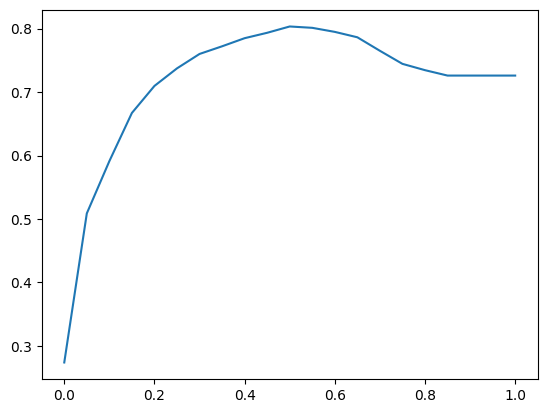

In [26]:
# to visually represent this threshold optimization process, we can create a plot.
plt.plot(thresholds, scores)

In [27]:
# using scikit learning built-in functions for evaluation  metrics
from sklearn.metrics import accuracy_score

In [28]:
thresholds = np.linspace(0, 1, 21)
scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('%.2f %.3f' %(t, score))
    scores.append(score)

0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.667
0.20 0.710
0.25 0.737
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.765
0.75 0.744
0.80 0.735
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


->> Checking accuracy of dummy baseline

- The Accuracy Paradox
This phenomenon is known as the Accuracy Paradox
. It occurs when a model's accuracy is high, but its predictive power for the target (minority) class is zero or near-zero
. Practitioners, especially beginners, may be misled into believing they have a high-performing model when, in reality, the model has "no skill" and is merely reflecting the underlying class distribution.

In [29]:
from collections import Counter

In [30]:
Counter (y_pred >= 1.0)

Counter({np.False_: 1409})

In [31]:
# distribution of y_val
Counter (y_val)

Counter({np.int64(0): 1023, np.int64(1): 386})

In [32]:
1023/1409

0.7260468417317246

In [33]:
y_val.mean()

np.float64(0.2739531582682754)

In [34]:
1-y_val.mean()

np.float64(0.7260468417317246)

- We can observe that there are significantly more non-churning customers than churning ones, with only 27% being churning customers and 73% being non-churning customers. This situation highlights a common challenge known as class imbalance, where one class has far more samples than the other.

In cases of class imbalance, the traditional accuracy metric can be misleading.

### Confusion table/matrix

->> The confusion matrix is a vital tool for evaluating the performance of a binary classification models. It allows us to examine the various errors and correct decisions made by our model.

In [35]:
# people who are going to churn
actual_positive = (y_val==1)
# people who are not going to churn
actual_negative = (y_val==0)

In [36]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

->> we'll examine the cases where both 'predict_postive' and 'actual_positive' are true.

In [37]:
# we'll examine the cases where both 'predict_poistive' and 'actual_positive' are true. This is precisely what the '&' operate represents, indicating a logican AND operation.
predict_positive & actual_positive

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [38]:
tp = (predict_positive & actual_positive).sum()
tp

np.int64(210)

In [39]:
tn = (predict_negative & actual_negative).sum()
tn

np.int64(922)

In [40]:
fp = (predict_positive & actual_negative).sum()
fp

np.int64(101)

In [41]:
fn = (predict_negative & actual_positive).sum()
fn

np.int64(176)

In [42]:
# arrange them in a table
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

In [43]:
confusion_matrix

array([[922, 101],
       [176, 210]])

->> we observe that we have more false-negatives than false positives. False positives represent customers who receive the email even though they are not likely to churn, resulting in a loss of money due to unecessary discounts. False negatives are customers who do not receive the email and end up leaving, causing financial losses as well. Both situations are undesirable.

Instead of using absolute numbers, we can express these values in relation terms to given a better perspective on the model's performance.

In [44]:
# Normalized
(confusion_matrix/confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

### Precision and Recall

->> Precision measures the fraction of positive predictions that were correct.

Precision = True Positive / (# Positive Prediction) = True Positive / (True Positive + False Positive)

->> Recall qualifies the fraction of actual positive cases that were correctly identified by the model.

Recall = True Positive / (# Positive Observation) = True Positive / (True Positive + False Negative)

In [45]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
accuracy

np.float64(0.8034066713981547)

In [46]:
precision = tp / (tp + fp)
precision

np.float64(0.6752411575562701)

-> Promotional email goes to 311 people but 210 are actually going to churn (33% are mistakes)

In [47]:
tp + fp

np.int64(311)

In [48]:
recall = tp / (tp + fn)
recall

np.float64(0.5440414507772021)

-> for 46% of people who are churning we failed to identify them
tp + fn

In [49]:
tp + fn

np.int64(386)

### ROC Curve (Receive Operating Characteristics)

->> The ROC curve visually represents the performance of a model by plotting the TPR (True Positive Rate or Sensitivity) against the FPR (False Positive Rate or 1-Specificity) at various threshold settings.

In [50]:
tpr = tp / (tp + fn)
tpr

np.float64(0.5440414507772021)

In [51]:
recall

np.float64(0.5440414507772021)

In [52]:
fpr = fp / (fp + tn)
fpr

np.float64(0.09872922776148582)

->> The ROC Curve is a useful visualization tool that allows you to access the performance of a binary classification model across a range of decision threshold

In [53]:
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (actual_positive & predict_positive).sum()
    tn = (actual_negative & predict_negative).sum()

    fp = (actual_negative & predict_positive).sum()
    fn = (actual_positive & predict_negative).sum()

    scores.append((t, tp, tn, fp, fn))

scores

[(np.float64(0.0), np.int64(386), np.int64(0), np.int64(1023), np.int64(0)),
 (np.float64(0.01), np.int64(385), np.int64(112), np.int64(911), np.int64(1)),
 (np.float64(0.02), np.int64(384), np.int64(194), np.int64(829), np.int64(2)),
 (np.float64(0.03), np.int64(383), np.int64(257), np.int64(766), np.int64(3)),
 (np.float64(0.04), np.int64(381), np.int64(308), np.int64(715), np.int64(5)),
 (np.float64(0.05), np.int64(379), np.int64(338), np.int64(685), np.int64(7)),
 (np.float64(0.06), np.int64(377), np.int64(363), np.int64(660), np.int64(9)),
 (np.float64(0.07), np.int64(372), np.int64(382), np.int64(641), np.int64(14)),
 (np.float64(0.08), np.int64(371), np.int64(410), np.int64(613), np.int64(15)),
 (np.float64(0.09), np.int64(369), np.int64(443), np.int64(580), np.int64(17)),
 (np.float64(0.1), np.int64(366), np.int64(467), np.int64(556), np.int64(20)),
 (np.float64(0.11), np.int64(365), np.int64(495), np.int64(528), np.int64(21)),
 (np.float64(0.12), np.int64(365), np.int64(514), 

->> we end up with 101 confusion matrices evaluated for different threshold. Let's turn that into a dataframe

In [54]:
columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,threshold,tp,tn,fp,fn
0,0.00,386,0,1023,0
1,0.01,385,112,911,1
2,0.02,384,194,829,2
3,0.03,383,257,766,3
4,0.04,381,308,715,5
...,...,...,...,...,...
96,0.96,0,1023,0,386
97,0.97,0,1023,0,386
98,0.98,0,1023,0,386
99,0.99,0,1023,0,386


->> we can look at each tenth record by using this column 10 operator. This works by pointing every record starting from the first record and moving forward with increments of 10.

In [55]:
df_scores[::10]

,threshold,tp,tn,fp,fn
0,0.0,386,0,1023,0
10,0.1,366,467,556,20
20,0.2,333,667,356,53
30,0.3,284,787,236,102
40,0.4,249,857,166,137
50,0.5,210,922,101,176
60,0.6,150,970,53,236
70,0.7,75,1003,20,311
80,0.8,13,1022,1,373
90,0.9,0,1023,0,386


In [56]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
df_scores[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.1,366,467,556,20,0.948187,0.543500
20,0.2,333,667,356,53,0.862694,0.347996
30,0.3,284,787,236,102,0.735751,0.230694
40,0.4,249,857,166,137,0.645078,0.162268
50,0.5,210,922,101,176,0.544041,0.098729
60,0.6,150,970,53,236,0.388601,0.051808
70,0.7,75,1003,20,311,0.194301,0.019550
80,0.8,13,1022,1,373,0.033679,0.000978
90,0.9,0,1023,0,386,0.000000,0.000000


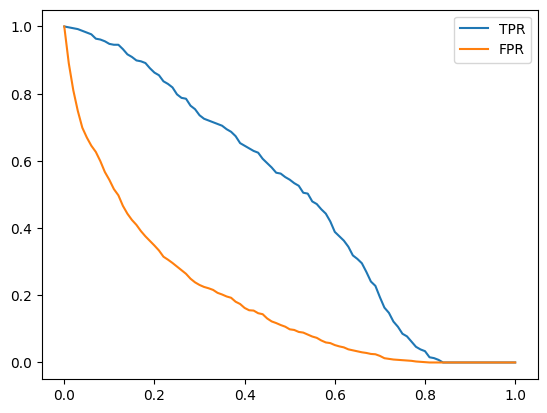

In [57]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

### Random Model

In [58]:
# random baseline model 
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))
y_rand.round(3)

array([0.417, 0.72 , 0.   , ..., 0.774, 0.334, 0.089], shape=(1409,))

In [59]:
# accuracy for our ramdom model is around 50%
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [60]:
# let's put the previously used code into a function
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace (0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
        
        tp = (actual_positive & predict_positive).sum()
        tn = (actual_negative & predict_negative).sum()
        
        fp = (actual_negative & predict_positive).sum()
        fn = (actual_positive & predict_negative).sum()
        
        scores.append((t, tp, tn, fp, fn))

    columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.1,347,100,923,39,0.898964,0.902248
20,0.2,307,201,822,79,0.795337,0.803519
30,0.3,276,299,724,110,0.715026,0.707722
40,0.4,237,399,624,149,0.613990,0.609971
50,0.5,202,505,518,184,0.523316,0.506354
60,0.6,161,614,409,225,0.417098,0.399804
70,0.7,121,721,302,265,0.313472,0.295210
80,0.8,78,817,206,308,0.202073,0.201369
90,0.9,40,922,101,346,0.103627,0.098729


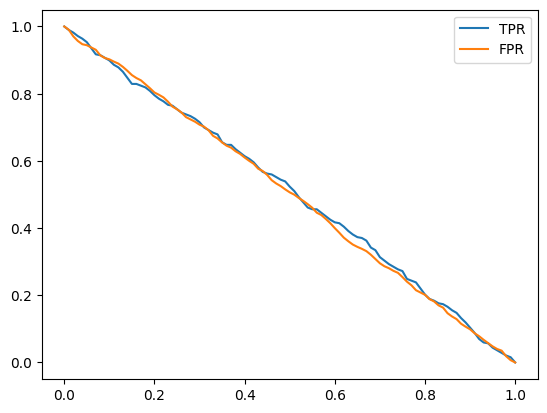

In [61]:
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()

### Ideal Model

->> now, let's talk about the concept of an ideal model that makes correct predictions for every example. To implement this, we use to determine the number of negative examples, which corresponds to the number of people who are not churning in our dataset.

In [62]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()

num_neg, num_pos

(np.int64(1023), np.int64(386))

->> To create the ideal model's prediction for our validation set, we first create a y_ideal array that contains only negative observations (0s) followed by positive observations (1s). We use the np.repeat() function to achieve this, creating an array with 1023 zeros and then 386 ones.

In [63]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

->> to create our predictions for the ideal model, which are numbers between 0 and 1, we can use the np.linspace function to generate an array of evenly spread values between 0 and 1.
This array should have the same length as y_ideal, which is 1409 in this case.

In [64]:
y_ideal_pred = np.linspace(0, 1, len(y_ideal))
y_ideal_pred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00], shape=(1409,))

In [65]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [66]:
accuracy_ideal = ((y_ideal_pred >= 0.726) == y_ideal).mean()
accuracy_ideal

np.float64(1.0)

->> The ideal model, which makes perfect predictions, doesn’t exist in reality, but it serves as a benchmark to understand how well our actual model is performing. By comparing our model’s performance to that of the ideal model, we can assess how much room for improvement there is.

In [67]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.1,386,141,882,0,1.000000,0.862170
20,0.2,386,282,741,0,1.000000,0.724340
30,0.3,386,423,600,0,1.000000,0.586510
40,0.4,386,564,459,0,1.000000,0.448680
50,0.5,386,704,319,0,1.000000,0.311828
60,0.6,386,845,178,0,1.000000,0.173998
70,0.7,386,986,37,0,1.000000,0.036168
80,0.8,282,1023,0,104,0.730570,0.000000
90,0.9,141,1023,0,245,0.365285,0.000000


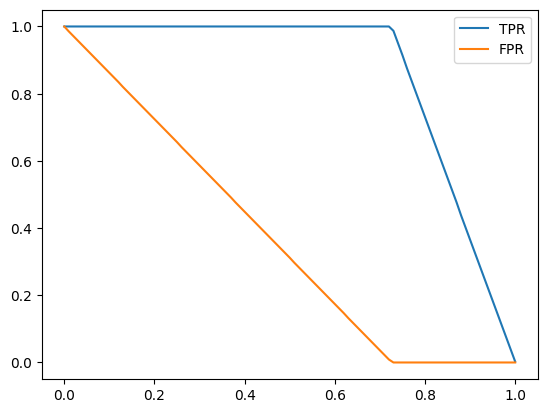

In [68]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

->> What we see here is that TPR almost always stays around 1 and starts to go down after the threshold of 0.726. So, this model can correctly identify churning customers up to that threshold. For people who are not churning but are classified as churning by the model when the threshold is below 0.726, the model is not always correct. However, the detection becomes always true after the threshold of 0.726.

Let’s take another example with a threshold of 0.4. The FPR is around 45%, and the model makes some mistakes. So, for around 32% of people who are predicted as non-churning when the threshold is set to 0.726 but are below that threshold, we predict them as churning even though they are not.

->> Putting them together

Now, let's try to plot all the models together so we can hold the benchmarks together.

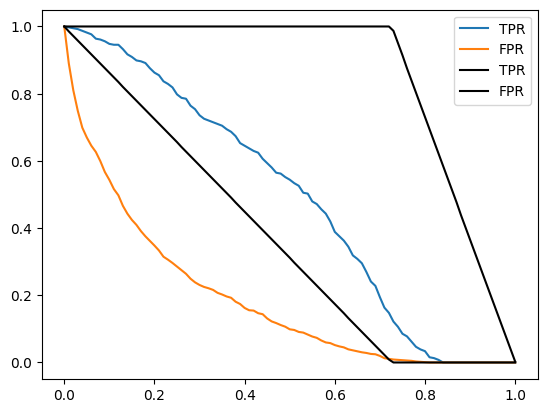

In [69]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')

# plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
# plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')

plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR', color='black')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR', color='black')
plt.legend()

->> We see that our TPR is far from the ideal model. We want it to be as close as possible to 1. We also notice that our FPR is significantly different from that of the ideal model. Plotting against the threshold is not always intuitive. For example, in our model, the best threshold is 0.5, as we know from accuracy. However, for the ideal model, as we saw earlier, the best threshold is 0.726. So they have different thresholds. What we can do to better visualize this is to plot FPR against TPR. On the x-axis, we’ll have FPR, and on the y-axis, we’ll have TPR. To make it easier to understand, we can also add the benchmark lines.

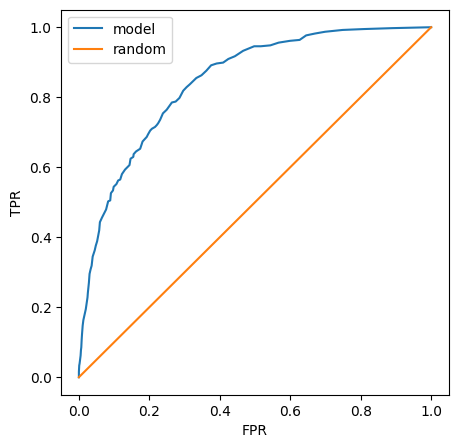

In [70]:
plt.figure(figsize = (5, 5))
plt.plot(df_scores.fpr, df_scores.tpr, label='model')
plt.plot([0, 1], [0, 1], label='random')
# plt.plot(df_rand.fpr, df_rand.tpr, label='random')
# plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

->> In the curve of the ideal model, there is one crucial point, often referred to as the ‘north star’ or ideal spot, located in the upper-left corner where TPR is 100% and FPR is 0%. This point represents the optimal performance we aim to achieve with our model. A ROC curve visualizes this by plotting TPR against FPR, and we usually add a diagonal random baseline. Our goal is to make our model’s curve as close as possible to this ideal spot, which means simultaneously being as far away as possible from the random baseline. In essence, if our model closely resembles the random baseline model, it is not performing well.

In [71]:
# we can also use the ROC functionality of scikit learn package
from sklearn.metrics import roc_curve

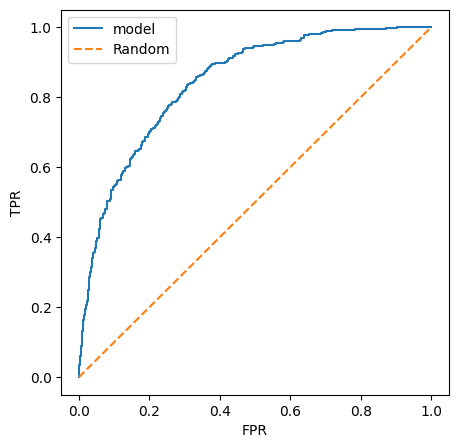

In [72]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

plt.figure(figsize = (5, 5))
plt.plot(fpr, tpr, label='model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

### What kind of information do we get from ROC curve?

->> Let’s begin in the lower-left corner, where both TPR and FPR are 0. This occurs at higher thresholds like 1.0. In this scenario, we predict that every customer is non-churning, resulting in TPR being 0 since we don’t predict anyone as churning. FPR is also 0 because there are no false positives; we only have true negatives (TN).

As we move from the lower left corner, where the threshold starts at 1.0, we eventually reach the upper-right corner with a threshold of 0.0. Here, our model achieves 100% TPR because we predict everyone as churning, enabling us to identify all churning customers. However, we also make many mistakes, incorrectly identifying non-churning customers. Thus, we have TPR = FPR = 100%.

When we adjust the threshold, we predict more customers as churning, causing our TPR to increase, but the FPR also increases concurrently.

The ROC curve allows us to observe how the model behaves at different thresholds. Each point on the ROC curve represents TPR and FPR evaluated at a specific threshold. By plotting this curve, we can assess how far the model is from the ideal spot and how far it is from the random baseline. Additionally, the ROC curve is useful for comparing different models, as it’s easy to determine which one is superior (a model closer to the ideal spot is better, while one closer to the random baseline is worse).

There is an interesting metric derived from the ROC curve known as AUC, which stands for the area under the curve.

### ROC AUC - Area under the ROC Curve

->> Useful metric

One way to quantify how close we are to the ideal point is by measuring the area under the ROC curve (AUC). AUC equals 0.5 for a random baseline and 1.0 for an ideal curve. Therefore, our model’s AUC should fall between 0.5 and 1.0. When AUC is less than 0.5, we’ve made a mistake. AUC = 0.8 is considered good, while 0.9 is great, but 0.6 is considered poor. We can calculate AUC using the scikit-learn package. This package is not specifically for roc curves, this is for any curve. It can calculate area under any curve.

In [73]:
from sklearn.metrics import auc

In [74]:
# auc needs values for x-axis and y-axis
auc(fpr, tpr)

0.8438454408703447

In [75]:
auc(df_scores.fpr, df_scores.tpr)

0.8437909936739956

In [76]:
auc(df_ideal.fpr, df_ideal.tpr)

0.9999430203759136

In [77]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.8438454408703447

In [78]:
# this is a shortcut in scikit-learn package
from sklearn.metrics import roc_auc_score

In [79]:
roc_auc_score(y_val, y_pred)

0.8438454408703447

->> AUC interpretation

AUC tells us the probability that a randomly selected positive example has a score that is higher than a randomly selected negative example

In [80]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [81]:
import random
pos_ind = random.randint(0, len(pos) -1)
neg_ind = random.randint(0, len(neg) -1)

In [82]:
# we want to compare the score of this positive example with the score of the negative example
pos[pos_ind] > neg[neg_ind]

np.True_

- so, for this random example, this is true. we can do this 100,000 times and evaluate the performance.

In [83]:
n = 100000
success = 0

for i in range(n):
    pos_ind = random.randint(0, len(pos) - 1)
    neg_ind = random.randint(0, len(neg) -1)

    if pos[pos_ind] > neg[neg_ind]:
        success += 1

success / n

0.84435

- the result is quite close to roc_auc_score(y_val, y_pred)

Instead of implementing this manually, we can use Numpy. Be aware that in np.random.randint(low, high, size, dtype), 'low' is inclusive and 'high' is exclusive.

In [84]:
n = 50000

np.random.seed(1)
pos_ind = np.random.randint(0, len(pos), size = n)
neg_ind = np.random.randint(0, len(neg), size = n)
pos[pos_ind] > neg[neg_ind]

(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.84646)

->> Because of this interpretation, AUC is quite popular as a way of measuring the performance of binary classification models. It’s quite intuitive, and we can use it to assess how well our model ranks positive and negative examples and separates positive examples from negative ones.

### Cross Validation

In [85]:
# this is used for assessing the same model on various subsets of our dataset
def train(df_train, y_train):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [86]:
dv, model = train(df_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [87]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.fit_transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [88]:
y_pred = predict(df_val, dv, model)
y_pred

array([0.0068843 , 0.20656064, 0.21837141, ..., 0.15168185, 0.78298062,
       0.81322261], shape=(1409,))

->> We now have the ‘train’ and ‘predict’ functions in place. Let’s proceed to implement K-Fold Cross-Validation.

In [89]:
from sklearn.model_selection import KFold

In [90]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

kfold.split(df_full_train)

train_idx, val_idx = next(kfold.split(df_full_train))
len(train_idx), len(val_idx)

(5070, 564)

In [91]:
len(df_full_train)

5634

In [92]:
# we can iloc to select a part of this dataframe
df_train = df_full_train.iloc[train_idx]
df_val = df_full_train.iloc[val_idx]

->> The following code snippet demonstrates the implementation for 10 folds. Finally, we use the ‘roc_auc_score’ function to calculate and output the corresponding score for each fold.

In [93]:
# let's apply all 10 folds
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx] # Split data
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.churn.values  # Prepare targets
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train) # Train model
    y_pred = predict(df_val, dv, model) # Validate

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

scores

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

[0.8499276434012372,
 0.8424814356435643,
 0.8583127086690031,
 0.8333223602995639,
 0.824643300248139,
 0.8413419913419913,
 0.8431292738521654,
 0.8253557874762808,
 0.8459759893285905,
 0.8612819737151692]

In [94]:
# same implementation, but this time with tqdm package
from sklearn.model_selection import KFold
!pip3 install tqdm
from tqdm.auto import tqdm

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in tqdm (kfold.split(df_full_train)):
    df_train = df_full_train.iloc[train_idx] # Split data
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.churn.values  # Prepare targets
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train) # Train model
    y_pred = predict(df_val, dv, model) # Validate

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

scores

0it [00:00, ?it/s]

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

[0.8499276434012372,
 0.8424814356435643,
 0.8583127086690031,
 0.8333223602995639,
 0.824643300248139,
 0.8413419913419913,
 0.8431292738521654,
 0.8253557874762808,
 0.8459759893285905,
 0.8612819737151692]

In [95]:
# getting the average prediction and the spread within predictions
print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.843 +- 0.012


- We can utilize the scores generated to compute the average score across the 10 folds, which is 84.3%, with a standard deviation of 0.012.

### Parameter Tuning

In [96]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [97]:
dv, model = train(df_train, y_train, C=0.001)

->> We can iterate over various values for ‘C,’ keeping in mind that ‘C’ cannot be set to 0.0, as it would result in an ‘InvalidParameterError.’ The ‘C’ parameter for LogisticRegression must be a float within the range (0.0, inf], so we need to avoid using 0.0.

In [98]:
from sklearn.model_selection import KFold

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

for C in [0.001, 0.01, 0.1, 1, 5, 10]:
    
    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

->> Afterwards, we aim to train our final model using the entire training dataset (df_full_train) and then validate it using the test dataset.

In [102]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8583517501381259

->> We observe that the AUC is slightly better than what we observed during k-fold cross-validation, though not significantly higher. This is expected when the difference is small.

In terms of when to use cross-validation versus traditional hold-out validation, for larger datasets, standard hold-out validation is often sufficient. However, if your dataset is smaller or you require insight into the model’s stability and variation across folds, then cross-validation is more appropriate. For larger datasets, consider using fewer splits (e.g., 2 or 3), while for smaller datasets, a higher number of splits (e.g., 10) may be beneficial.